## Visualize the results for the two body problem

In [ ]:
# path = '/root/work/dhn-deeplearning/results/ar/two_body_kernel2_stride1/gen_sequence/denoise1_update1/result_dict.npy'
path = '/root/work/dhn-deeplearning/results/ar/two_body_kernel2_stride1/gen_sequence/denoise5_update1/result_dict.npy'
path_cond = '/root/work/dhn-deeplearning/results/ar/two_body_kernel2_stride1/gen_sequence/denoise5_update1/cond_dict.npy'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

data = np.load(path, allow_pickle=True).item()
cond = np.load(path_cond, allow_pickle=True).item()
print(data.keys())
print(cond.keys())

### Reproducing the paper plots

In [1]:
# path = '/root/work/dhn-deeplearning/results/ar/two_body_kernel2_stride1/gen_sequence/denoise1_update1/result_dict.npy'
path = '/root/work/dhn-deeplearning/results/ar/two_body_kernel2_stride1/gen_sequence/denoise5_update1/result_dict.npy'
path_cond = '/root/work/dhn-deeplearning/results/ar/two_body_kernel2_stride1/gen_sequence/denoise5_update1/cond_dict.npy'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

data = np.load(path, allow_pickle=True).item()
cond = np.load(path_cond, allow_pickle=True).item()
print(data.keys())
print(cond.keys())

dict_keys(['t', 'q_gt', 'p_gt', 'q_pred', 'p_pred', 'p_scale'])
dict_keys(['m1', 'm2', 'r1', 'r2'])


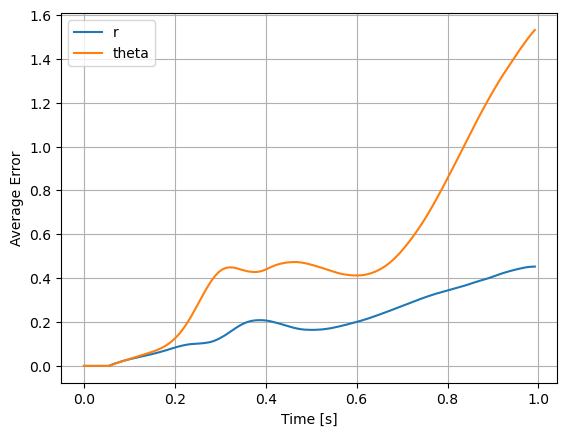

In [3]:
# Let's first do the average error on q over time plot

t=data['t']
q_gt=data['q_gt']
q_pred=data['q_pred']

r_gt=q_gt[:,:,0]
r_pred=q_pred[:,:,0]
theta_gt=q_gt[:,:,1]
theta_pred=q_pred[:,:,1]

residual_r=np.abs(r_gt-r_pred)
residual_theta=np.abs(theta_gt-theta_pred)

plt.plot(t[0], residual_r.mean(axis=0), label='r')
plt.plot(t[0], residual_theta.mean(axis=0), label='theta')
plt.xlabel('Time [s]')
plt.ylabel('Average Error')
plt.legend()
plt.grid(True)
plt.show()


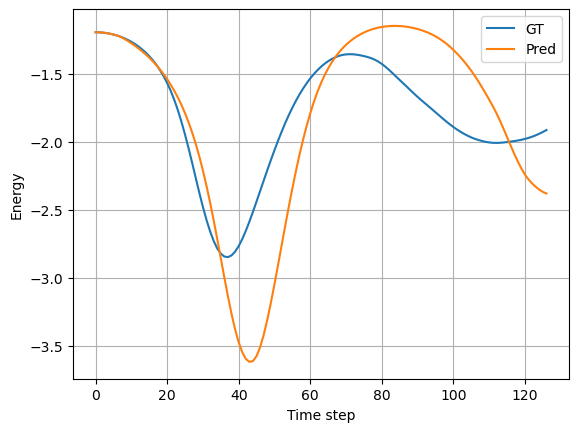

In [ ]:
# Now let's calculate the energy over time

m1 = cond['m1']
m2 = cond['m2']
mu = m1*m2/(m1+m2)
G = 1.0

q_gt=data['q_gt']
q_pred=data['q_pred']

r_gt=q_gt[:,:,0]
r_pred=q_pred[:,:,0]
theta_gt=q_gt[:,:,1]
theta_pred=q_pred[:,:,1]


# dt = t[0,1:] - t[0,:-1]    # (T-1,)
dt=np.ones(t.shape[1]-1)

dr_gt = (r_gt[:,1:] - r_gt[:,:-1])/dt[None,:]
dr_pred = (r_pred[:,1:] - r_pred[:,:-1])/dt[None,:]

dtheta_gt = (theta_gt[:,1:] - theta_gt[:,:-1])/dt[None,:]
dtheta_pred = (theta_pred[:,1:] - theta_pred[:,:-1])/dt[None,:]


# T = mu/2 * (dr**2 + r**2 * dtheta**2)
# V = -G*M/r

T_gt = mu.reshape(-1,1)/2 * (dr_gt**2 + (r_gt[:,:-1])**2 * dtheta_gt**2)
T_pred = mu.reshape(-1,1)/2 * (dr_pred**2 + (r_pred[:,:-1])**2 * dtheta_pred**2)

V_gt = -(G*m1*m2).reshape(-1,1)/r_gt[:,:-1]
V_pred = -(G*m1*m2).reshape(-1,1)/r_pred[:,:-1]

E_gt = T_gt + V_gt
E_pred = T_pred + V_pred

plt.plot(E_gt.mean(axis=0), label='GT')
plt.plot(E_pred.mean(axis=0), label='Pred')
plt.xlabel('Time step')
plt.ylabel('Energy')
plt.legend()
plt.grid(True)
plt.show()